In [3]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"/content/used_cars_powerful.csv")

In [4]:
data.head()

,Brand,Model Year,Mileage,Fuel Type,Condition,Transmission,Resale Price
0,Honda,2011,74152,Gasoline,2,Automatic,22070
1,Mercedes,2015,60180,Electric,4,Manual,56002
2,BMW,2014,81297,Electric,4,Automatic,51684
3,Mercedes,2013,17194,Diesel,1,Manual,44400
4,Mercedes,2018,31986,Gasoline,5,Manual,52688


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         2000 non-null   object
 1   Model Year    2000 non-null   int64 
 2   Mileage       2000 non-null   int64 
 3   Fuel Type     2000 non-null   object
 4   Condition     2000 non-null   int64 
 5   Transmission  2000 non-null   object
 6   Resale Price  2000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 109.5+ KB


In [6]:
data.isna().sum()

,0
Brand,0
Model Year,0
Mileage,0
Fuel Type,0
Condition,0
Transmission,0
Resale Price,0


In [7]:
from sklearn.preprocessing import LabelEncoder
cat_columns = ["Brand" , "Fuel Type" , "Transmission"]
le = {}
for col in cat_columns:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

In [8]:
data.head()

,Brand,Model Year,Mileage,Fuel Type,Condition,Transmission,Resale Price
0,2,2011,74152,2,2,0,22070
1,3,2015,60180,1,4,1,56002
2,0,2014,81297,1,4,0,51684
3,3,2013,17194,0,1,1,44400
4,3,2018,31986,2,5,1,52688


In [9]:
from sklearn.preprocessing import StandardScaler
num_columns = ["Model Year" , "Mileage" , "Condition" ]
scale = StandardScaler()
data[num_columns] = scale.fit_transform(data[num_columns])

In [10]:
data.head()

,Brand,Model Year,Mileage,Fuel Type,Condition,Transmission,Resale Price
0,2,-0.592890,0.728586,2,-0.696894,0,22070
1,3,0.094618,0.017762,1,0.692033,1,56002
2,0,-0.077259,1.092087,1,0.692033,0,51684
3,3,-0.249136,-2.169146,0,-1.391357,1,44400
4,3,0.610249,-1.416605,2,1.386496,1,52688


In [13]:
summary = data.describe()
print(summary)

             Brand    Model Year       Mileage    Fuel Type     Condition  \
count  2000.000000  2.000000e+03  2.000000e+03  2000.000000  2.000000e+03   
mean      2.040000  9.720669e-15  2.531308e-17     0.987500  1.314504e-16   
std       1.411523  1.000250e+00  1.000250e+00     0.823822  1.000250e+00   
min       0.000000 -1.624152e+00 -3.043889e+00     0.000000 -1.391357e+00   
25%       1.000000 -9.366437e-01 -6.807376e-01     0.000000 -6.968939e-01   
50%       2.000000 -7.725871e-02 -2.502398e-02     1.000000 -2.430621e-03   
75%       3.000000  9.540033e-01  6.970305e-01     2.000000  6.920326e-01   
max       4.000000  1.641511e+00  3.124080e+00     2.000000  1.386496e+00   

       Transmission  Resale Price  
count   2000.000000   2000.000000  
mean       0.521500  36109.489000  
std        0.499662  10948.022104  
min        0.000000  13467.000000  
25%        0.000000  27040.500000  
50%        1.000000  34341.500000  
75%        1.000000  44917.750000  
max        1.00000

<Axes: xlabel='Resale Price', ylabel='Count'>

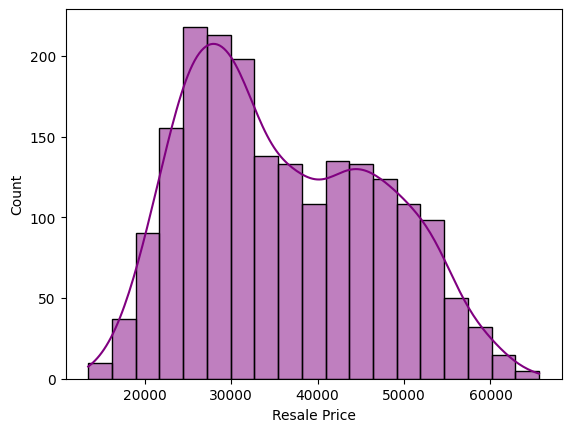

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data["Resale Price"] , color = "purple" , kde = True)

<Axes: xlabel='Mileage', ylabel='Resale Price'>

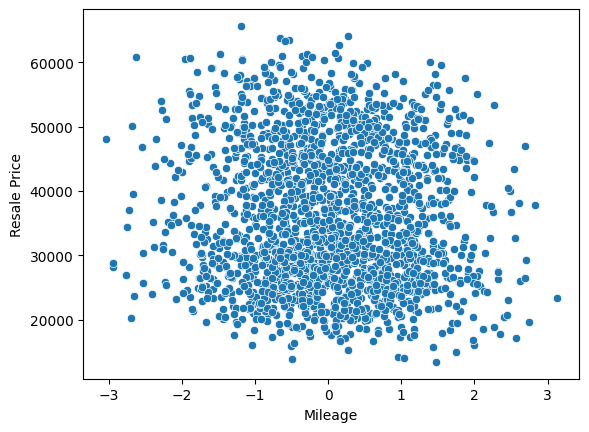

In [15]:
sns.scatterplot(data = data , x = "Mileage" , y = "Resale Price")

<Axes: xlabel='Brand', ylabel='Resale Price'>

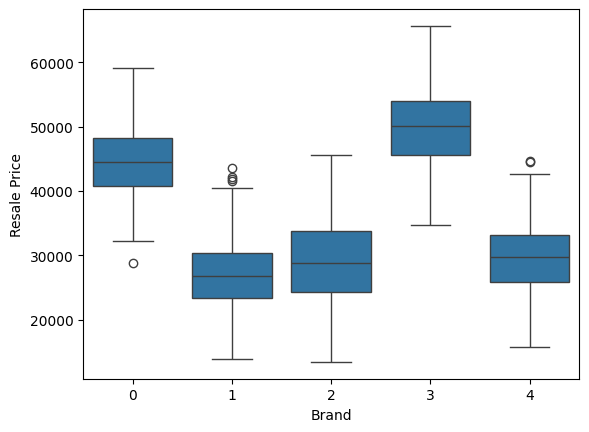

In [16]:
sns.boxplot(data = data , x = "Brand" , y = "Resale Price")

In [17]:
from sklearn.model_selection import train_test_split
x = data.drop("Resale Price" , axis = 1)
y = data["Resale Price"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
lr = LinearRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("MAE = " , mean_absolute_error(y_test , lr_y_pred))
print("MSE = " , mean_squared_error(y_test , lr_y_pred))
print("R2_score = " , r2_score(y_test , lr_y_pred))




MAE =  8572.322485303583
MSE =  97060216.70607479
R2_score =  0.15691594341551607


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
rf = RandomForestRegressor()
rf.fit(x_train , y_train)
rf_y_pred = rf.predict(x_test)
print("MAE = " , mean_absolute_error(y_test , rf_y_pred))
print("MSE = " , mean_squared_error(y_test , rf_y_pred))
print("R2_score = " , r2_score(y_test , rf_y_pred))


MAE =  1942.7851749999995
MSE =  6084549.70398125
R2_score =  0.9471484092967065


In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
dt = DecisionTreeRegressor()
dt.fit(x_train , y_train)
dt_y_pred = dt.predict(x_test)
print("MAE = " , mean_absolute_error(y_test , dt_y_pred))
print("MSE = " , mean_squared_error(y_test , dt_y_pred))
print("R2_score = " , r2_score(y_test , dt_y_pred))


MAE =  2645.9
MSE =  12002939.14
R2_score =  0.8957401192320383


In [26]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
grid_params = {
    "max_depth" : [x for x in range(30,70)],
    "max_leaf_nodes" : [x for x in range(50,80)],
}
grid_model = GridSearchCV(DecisionTreeRegressor() , grid_params , cv = 5)
grid_model.fit(x_train , y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 30, 'max_leaf_nodes': 63}
0.9004784708792757


In [27]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
random_params = {
    "n_estimators" : [x for x in range(30,70)],
    "max_depth" : [x for x in range(50,80)],
}
random_model = RandomizedSearchCV(RandomForestRegressor() , random_params , cv = 5)
random_model.fit(x_train , y_train)
print(random_model.best_estimator_)
print(random_model.best_score_)

RandomForestRegressor(max_depth=71, n_estimators=45)
0.946249573298344


In [28]:
data.columns

Index(['Brand', 'Model Year', 'Mileage', 'Fuel Type', 'Condition',
       'Transmission', 'Resale Price'],
      dtype='object')

In [29]:
def predict(Brand , Model_Year , Mileage , Fuel_Type , Condition , Transmission):
    try:
        input_data = pd.DataFrame({
            "Brand" : [Brand],
            "Model Year" : [Model_Year],
            "Mileage" : [Mileage],
            "Fuel Type" : [Fuel_Type],
            "Condition" : [Condition],
            "Transmission" : [Transmission],
        })
        for col in cat_columns:
            input_data[col] = le[col].transform(input_data[col])
        input_data[num_columns] = scale.transform(input_data[num_columns])
        prediction = rf.predict(input_data)[0]
        return f"price = {prediction}"
    except Exception as e:
        return f"Error {e}"


In [30]:
import gradio as gr
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Brand" , choices = ["BMW" , "Ford" , "Honda" , "Mercedes" , "Toyota"]),
        gr.Number(label = "Model Year"),
        gr.Number(label = "Mileage"),
        gr.Dropdown(label = "Fuel Type" , choices = ["Diesel" , "Electric" , "Gasoline"]),
        gr.Number(label = "Condition"),
        gr.Dropdown(label = "Transmission" , choices = ["Automatic" , "Manual" ]),
    ],
    outputs = "text",
    title = "Predicting car price",
).launch()





It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3ec5036ed13f514709.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
